In [1]:
# =============================================================================
# Week 2 – GAT Model + Tox21 Classification + Metrics & Plots
# =============================================================================

import torch
import torch.nn.functional as F
import torch_geometric                             # ← Add this line
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet
from torch_geometric.transforms import BaseTransform
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Torch: {torch.__version__}   |   PyG: {torch_geometric.__version__}")

Device: cuda
Torch: 2.3.1+cu118   |   PyG: 2.7.0


In [2]:
class CastToFloat(BaseTransform):
    def forward(self, data):
        data.x = data.x.to(torch.float32)
        if hasattr(data, 'edge_attr') and data.edge_attr is not None:
            data.edge_attr = data.edge_attr.to(torch.float32)
        return data

In [46]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# ─── ESOL (solubility regression) ───
esol = MoleculeNet(root='./data/MoleculeNet', name='ESOL', transform=CastToFloat())
print(f"ESOL: {len(esol)} molecules, {esol.num_node_features} node features")

# ESOL splits (regression)
esol_train_idx, esol_test_idx = train_test_split(range(len(esol)), test_size=0.20, random_state=42)

esol_train_loader = DataLoader(
    esol[esol_train_idx],
    batch_size=32,
    shuffle=True,
    follow_batch=['global_feats']          # ← ADD THIS LINE (critical for custom attributes)
)

esol_test_loader = DataLoader(
    esol[esol_test_idx],
    batch_size=32,
    shuffle=False,
    follow_batch=['global_feats']          # ← ADD THIS LINE here too
)

# ─── Tox21 (multi-label toxicity classification) ───
tox21 = MoleculeNet(root='./data/MoleculeNet', name='Tox21', transform=CastToFloat())
print(f"Tox21: {len(tox21)} molecules, 12 tasks (Tox21 is fixed at 12 labels)")
print("Tox21 task names (from MoleculeNet source):")
print([
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
])

# Tox21 splits (classification) — no globals needed here, so follow_batch not required
tox_train_idx, tox_test_idx = train_test_split(range(len(tox21)), test_size=0.20, random_state=42)

tox_train_loader = DataLoader(tox21[tox_train_idx], batch_size=32, shuffle=True)
tox_test_loader = DataLoader(tox21[tox_test_idx], batch_size=32, shuffle=False)

print(f"ESOL train/test: {len(esol_train_loader.dataset)} / {len(esol_test_loader.dataset)}")
print(f"Tox21 train/test: {len(tox_train_loader.dataset)} / {len(tox_train_loader.dataset)}")

Processing...


ESOL: 1128 molecules, 9 node features
Tox21: 7831 molecules, 12 tasks (Tox21 is fixed at 12 labels)
Tox21 task names (from MoleculeNet source):
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
ESOL train/test: 902 / 226
Tox21 train/test: 6264 / 6264


Done!


In [25]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_add_pool

class GATv2ResRegressionBig(torch.nn.Module):
    """Bigger + tuned GATv2-Res for better capacity on ESOL – FIXED forward extraction"""
    def __init__(self, in_channels, global_feat_dim=0, hidden_channels=128, heads=6, dropout=0.2):
        super().__init__()
        self.global_feat_dim = global_feat_dim
        
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads,
                               dropout=dropout, negative_slope=0.2, residual=True)
        self.norm1 = torch.nn.LayerNorm(hidden_channels * heads)
        
        self.conv2 = GATv2Conv(hidden_channels*heads, hidden_channels, heads=heads,
                               dropout=dropout, negative_slope=0.2, residual=True)
        self.norm2 = torch.nn.LayerNorm(hidden_channels * heads)
        
        self.conv3 = GATv2Conv(hidden_channels*heads, hidden_channels, heads=1,
                               concat=False, dropout=dropout, negative_slope=0.2,
                               residual=True)
        self.norm3 = torch.nn.LayerNorm(hidden_channels)
        
        pool_dim = hidden_channels * 2 + global_feat_dim  # mean + sum + globals
        self.lin1 = torch.nn.Linear(pool_dim, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, 1)

    def forward(self, data):
        # FIXED: correct attribute access
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Optional: global features support (still works even if not present)
        global_feats = getattr(data, 'global_feats', None)
        
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.elu(x)
        
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.elu(x)
        
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.elu(x)
        
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)
        
        if global_feats is not None:
            x_pool = torch.cat([x_pool, global_feats], dim=-1)
        
        x = F.dropout(x_pool, p=0.1, training=self.training)
        x = self.lin1(x)
        x = F.elu(x)
        return self.lin2(x)

In [26]:
@torch.no_grad()
def eval_regression(loader, model):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch).squeeze(-1)
        preds.append(out.cpu())
        trues.append(batch.y.squeeze(-1).cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae  = mean_absolute_error(trues, preds)
    return rmse, mae, preds, trues


def train_regression_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0
    n_graphs = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = F.mse_loss(out.squeeze(-1), batch.y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n_graphs += batch.num_graphs
    avg_loss = total_loss / n_graphs
    if scheduler is not None:
        scheduler.step()
    return avg_loss

Starting GATv2-Res Big training on ESOL
Model parameters: 2,128,129
Device: cuda
→ New best RMSE: 1.8313   MAE: 1.4788   (epoch 1)
Epoch    1 | Train loss 9.20924 | Test RMSE 1.8313 | MAE 1.4788 | LR 1.00e-03
→ New best RMSE: 1.7666   MAE: 1.3280   (epoch 2)
Epoch    2 | Train loss 3.61229 | Test RMSE 1.7666 | MAE 1.3280 | LR 1.00e-03
Epoch    3 | Train loss 2.91001 | Test RMSE 2.0069 | MAE 1.4930 | LR 1.00e-03
Epoch    4 | Train loss 2.63780 | Test RMSE 1.7707 | MAE 1.2986 | LR 1.00e-03
→ New best RMSE: 1.6122   MAE: 1.2339   (epoch 5)
Epoch    5 | Train loss 3.42831 | Test RMSE 1.6122 | MAE 1.2339 | LR 9.99e-04
→ New best RMSE: 1.5795   MAE: 1.2384   (epoch 6)
Epoch    6 | Train loss 2.82044 | Test RMSE 1.5795 | MAE 1.2384 | LR 9.99e-04
→ New best RMSE: 1.4952   MAE: 1.1449   (epoch 7)
Epoch    7 | Train loss 2.40146 | Test RMSE 1.4952 | MAE 1.1449 | LR 9.99e-04
→ New best RMSE: 1.4297   MAE: 1.1138   (epoch 8)
Epoch    8 | Train loss 2.35260 | Test RMSE 1.4297 | MAE 1.1138 | LR 9.98

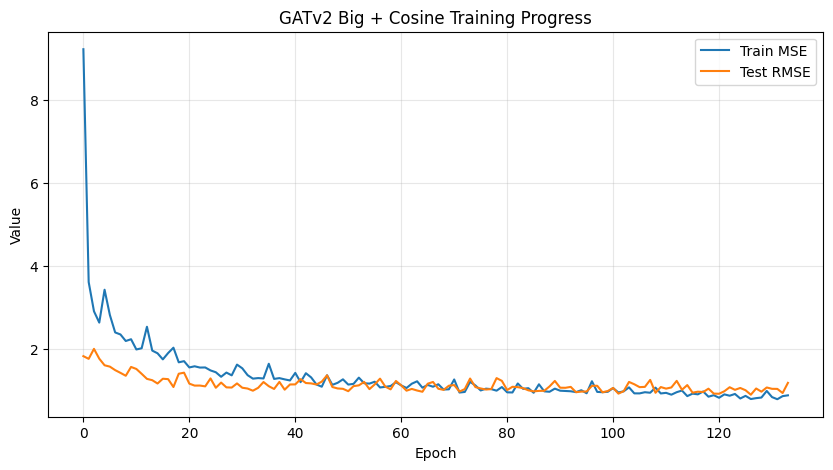

In [27]:
# =============================================================================
# Training GATv2-Res Big – Higher Capacity + Cosine Scheduler
# =============================================================================
gat_esol = GATv2ResRegressionBig(esol.num_node_features, global_feat_dim=0,hidden_channels=128, heads=6, dropout=0.2).to(device)

print(f"Starting GATv2-Res Big training on ESOL")
print(f"Model parameters: {sum(p.numel() for p in gat_esol.parameters()):,}")
print(f"Device: {device}")

optimizer = torch.optim.AdamW(
    gat_esol.parameters(),
    lr=0.001,             # higher start, cosine will decay
    weight_decay=5e-5
)

# Cosine annealing (common in recent mol GNN papers)
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-6)

max_epochs = 400   # can go longer with cosine
best_rmse = float('inf')
train_losses, test_rmses, test_maes = [], [], []

for epoch in range(1, max_epochs + 1):
    gat_esol.train()
    total_loss = 0.0
    n_graphs = 0
    
    for batch in esol_train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = gat_esol(batch)
        loss = F.mse_loss(out.squeeze(-1), batch.y.squeeze(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gat_esol.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        n_graphs += batch.num_graphs
    
    avg_train_loss = total_loss / n_graphs
    train_losses.append(avg_train_loss)
    
    rmse, mae, _, _ = eval_regression(esol_test_loader, gat_esol)
    test_rmses.append(rmse)
    test_maes.append(mae)
    
    scheduler.step()   # cosine every epoch
    
    if rmse < best_rmse:
        best_rmse = rmse
        torch.save(gat_esol.state_dict(), "best_esol_gatv2_big.pt")
        print(f"→ New best RMSE: {rmse:.4f}   MAE: {mae:.4f}   (epoch {epoch})")
    
    if epoch <= 15 or epoch % 25 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:4d} | Train loss {avg_train_loss:.5f} | "
              f"Test RMSE {rmse:.4f} | MAE {mae:.4f} | LR {current_lr:.2e}")
    
    # Very loose early stop
    if epoch > 120 and rmse > best_rmse * 1.25:
        print(f"Early stopping at epoch {epoch}")
        break

# Summary + plot (same as before)
print("\n" + "="*60)
print(f"Best GATv2-Res Big test RMSE: {best_rmse:.4f}")
print(f"Best model saved as: best_esol_gatv2_big.pt")
print("="*60)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE')
plt.plot(test_rmses, label='Test RMSE')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('GATv2 Big + Cosine Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [64]:
import shutil
import os

processed_dir = './data/MoleculeNet/ESOL/processed'  # adjust if your root is different

if os.path.exists(processed_dir):
    shutil.rmtree(processed_dir)
    print("Deleted old processed files – will re-process on next load")
else:
    print("No old processed directory found")

Deleted old processed files – will re-process on next load


In [65]:
from torch_geometric.transforms import BaseTransform
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

descriptor_names = [
    'MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds',
    'NumHDonors', 'NumHAcceptors', 'FractionCSP3', 'RingCount'
]

class AddRDKitGlobals(BaseTransform):
    def __init__(self, train_indices, scaler):
        self.train_indices = train_indices
        self.scaler = scaler

    def forward(self, data):
        mol = Chem.MolFromSmiles(data.smiles)
        if mol is None:
            raw = np.zeros(len(descriptor_names), dtype=np.float32)
        else:
            raw = np.array([
                Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumRotatableBonds(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                rdMolDescriptors.CalcFractionCSP3(mol),
                rdMolDescriptors.CalcNumRings(mol),
            ], dtype=np.float32)

        normalized = self.scaler.transform(raw.reshape(1, -1))[0]
        data.global_feats = torch.tensor(normalized, dtype=torch.float).unsqueeze(0)
        return data

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'

In [66]:
from torch_geometric.datasets import MoleculeNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# Temporary load without transform
esol_raw = MoleculeNet(root='./data/MoleculeNet', name='ESOL')

# Create split (same random seed you use later)
esol_train_idx, esol_test_idx = train_test_split(
    range(len(esol_raw)),
    test_size=0.20,
    random_state=42
)

# Compute raw descriptors for all
global_raw = []
for data in esol_raw:
    mol = Chem.MolFromSmiles(data.smiles)
    if mol is None:
        row = [0.0] * 8
    else:
        row = [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            rdMolDescriptors.CalcFractionCSP3(mol),
            rdMolDescriptors.CalcNumRings(mol),
        ]
    global_raw.append(row)

global_raw = np.array(global_raw, dtype=np.float32)

# Fit on train only
scaler = StandardScaler().fit(global_raw[esol_train_idx])

print("Scaler fitted on actual train split")
print("Mean:", scaler.mean_.round(4))
print("Std: ", scaler.scale_.round(4))

Processing...
Done!


Scaler fitted on actual train split
Mean: [204.4771   2.4458  35.0518   2.2084   0.7007   2.1397   0.4522   1.3758]
Std:  [103.6364   1.834   35.1616   2.6291   1.0702   2.1656   0.3758   1.309 ]


In [67]:
# Create transform
rdkit_transform = AddRDKitGlobals(
    train_indices=esol_train_idx,
    scaler=scaler
)

# Load dataset with the transform
esol = MoleculeNet(
    root='./data/MoleculeNet',
    name='ESOL',
    transform=rdkit_transform   # ← this line makes the difference
)

print(f"ESOL loaded with RDKit globals: {len(esol)} molecules")

ESOL loaded with RDKit globals: 1128 molecules


In [68]:
from torch_geometric.loader import DataLoader

# Use the SAME indices as before
esol_train_loader = DataLoader(
    esol[esol_train_idx],
    batch_size=32,
    shuffle=True,
    follow_batch=['global_feats']
)

esol_test_loader = DataLoader(
    esol[esol_test_idx],
    batch_size=32,
    shuffle=False,
    follow_batch=['global_feats']
)

print(f"Train size: {len(esol_train_loader.dataset)}")
print(f"Test size:  {len(esol_test_loader.dataset)}")

Train size: 902
Test size:  226


In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for batch in esol_train_loader:
    batch = batch.to(device)
    print("Batch has global_feats?", hasattr(batch, 'global_feats'))
    if hasattr(batch, 'global_feats'):
        print("global_feats shape:", batch.global_feats.shape)
        print("First sample globals:", batch.global_feats[0].flatten()[:8].tolist())
    break

Batch has global_feats? True
global_feats shape: torch.Size([32, 8])
First sample globals: [0.8208305835723877, 1.4716212749481201, -0.15903088450431824, -0.0792761892080307, 0.27968719601631165, -0.06450250744819641, -1.203283667564392, 0.4768233895301819]


In [75]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_add_pool

class GATv2ResSOTA(torch.nn.Module):
    """
    Improved GATv2 for ESOL regression with RDKit globals
    """
    def __init__(
        self,
        in_channels: int,
        edge_dim: int = 3,
        global_feat_dim: int = 8,
        hidden_channels: int = 128,
        heads: int = 6,
        dropout: float = 0.2,
    ):
        super().__init__()
        
        self.dropout = dropout
        self.global_feat_dim = global_feat_dim
        self.hidden_channels = hidden_channels
        
        self.conv1 = GATv2Conv(
            in_channels, hidden_channels, heads=heads,
            dropout=dropout, edge_dim=edge_dim,
            negative_slope=0.2, residual=True, add_self_loops=True
        )
        self.norm1 = torch.nn.LayerNorm(hidden_channels * heads)
        
        self.conv2 = GATv2Conv(
            hidden_channels * heads, hidden_channels, heads=heads,
            dropout=dropout, edge_dim=edge_dim,
            negative_slope=0.2, residual=True, add_self_loops=True
        )
        self.norm2 = torch.nn.LayerNorm(hidden_channels * heads)
        
        self.conv3 = GATv2Conv(
            hidden_channels * heads, hidden_channels, heads=1, concat=False,
            dropout=dropout, edge_dim=edge_dim,
            negative_slope=0.2, residual=True, add_self_loops=True
        )
        self.norm3 = torch.nn.LayerNorm(hidden_channels)
        
        self.pooled_dim = hidden_channels * 2 + global_feat_dim
        self.vn_emb = torch.nn.Parameter(torch.zeros(1, self.pooled_dim))
        
        self.lin1 = torch.nn.Linear(self.pooled_dim, hidden_channels * 2)
        self.lin2 = torch.nn.Linear(hidden_channels * 2, 1)

    def forward(self, data):
        x = data.x.float()  # ← FIX HERE: cast to float before dropout & convs
        
        edge_index = data.edge_index
        batch = data.batch
        edge_attr = data.edge_attr if hasattr(data, 'edge_attr') else None
        
        if not hasattr(data, 'global_feats'):
            raise RuntimeError("global_feats missing – check transform & follow_batch in DataLoader")
        
        global_feats = data.global_feats
        if global_feats.dim() == 3 and global_feats.size(1) == 1:
            global_feats = global_feats.squeeze(1)
        
        if global_feats.size(1) != self.global_feat_dim:
            raise RuntimeError(f"Wrong global_feats dim: {global_feats.size(1)} vs {self.global_feat_dim}")
        
        # Message passing
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.norm1(x)
        x = F.elu(x)
        
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.norm2(x)
        x = F.elu(x)
        
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        x = self.norm3(x)
        x = F.elu(x)
        
        # Pooling + concat globals
        x_mean = global_mean_pool(x, batch)
        x_sum = global_add_pool(x, batch)
        x_pool = torch.cat([x_mean, x_sum], dim=-1)
        x_pool = torch.cat([x_pool, global_feats], dim=-1)
        
        assert x_pool.size(1) == self.pooled_dim, \
            f"Dim mismatch: got {x_pool.size(1)}, expected {self.pooled_dim}"
        
        # Virtual node
        x_pool = x_pool + self.vn_emb
        
        # Readout
        x = F.dropout(x_pool, p=0.1, training=self.training)
        x = self.lin1(x)
        x = F.elu(x)
        x = self.lin2(x)
        
        return x.squeeze(-1)

In [71]:
# Debug: check shapes in a real batch
sample_batch = next(iter(esol_train_loader))

print("Batch info:")
print("  num_graphs:", sample_batch.num_graphs)
print("  x.shape:   ", sample_batch.x.shape)          # [total_nodes, 9]
print("  edge_index.shape:", sample_batch.edge_index.shape)  # [2, total_edges]
print("  edge_attr.shape:", getattr(sample_batch, 'edge_attr', None))  # should be [total_edges, 3]
print("  y.shape:   ", sample_batch.y.shape)
print("  global_feats.shape (if present):", getattr(sample_batch, 'global_feats', None))


Batch info:
  num_graphs: 32
  x.shape:    torch.Size([416, 9])
  edge_index.shape: torch.Size([2, 866])
  edge_attr.shape: tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        ...,
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1]])
  y.shape:    torch.Size([32, 1])
  global_feats.shape (if present): tensor([[-1.6829, -0.7740, -0.9969, -0.8400, -0.6547, -0.9880,  1.4576, -1.0510],
        [-0.8518, -0.2717, -0.4215,  0.6814,  0.2797, -0.5263,  1.4576, -1.0510],
        [-0.0798, -1.1684,  1.1438, -0.8400,  1.2140,  0.3973,  0.5706,  0.4768],
        [ 0.5969,  0.8171,  0.0639, -0.8400,  0.2797, -0.0645, -0.1685,  2.0047],
        [-0.3497,  0.4535, -0.9969, -0.0793, -0.6547, -0.9880, -0.9986,  0.4768],
        [-0.4275, -1.0595,  0.4991,  0.6814, -0.6547,  0.8590,  0.6973, -1.0510],
        [-1.2582, -1.2358, -0.2489, -0.8400, -0.6547, -0.0645,  0.5706, -1.0510],
        [ 1.8328,  0.6857,  0.8011,  0.3011, -0.6547,  1.7825, -0.2778,  2.7686],
     

In [72]:
# Quick debug – run this before training loop
for batch in esol_train_loader:   # or whatever your loader is called
    batch = batch.to(device)
    print("Batch has global_feats?", hasattr(batch, 'global_feats'))
    if hasattr(batch, 'global_feats'):
        print("global_feats shape:", batch.global_feats.shape)
    break   # just check first batch

Batch has global_feats? True
global_feats shape: torch.Size([32, 8])


In [73]:
import torch
import torch.nn.functional as F
import numpy as np
from torch_geometric.loader import DataLoader  # if not already imported

@torch.no_grad()
def eval_regression(loader, model):
    """
    Evaluate regression model on a loader.
    Returns: RMSE, MAE, all_preds (list), all_trues (list)
    """
    model.eval()
    all_preds = []
    all_trues = []
    
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)  # [batch_size, 1]
        
        # Collect predictions and targets
        preds = out.squeeze(-1).cpu().numpy()      # shape [batch_size]
        trues = batch.y.squeeze(-1).cpu().numpy()  # shape [batch_size]
        
        all_preds.extend(preds.tolist())
        all_trues.extend(trues.tolist())
    
    all_preds = np.array(all_preds)
    all_trues = np.array(all_trues)
    
    # Compute metrics
    mse = np.mean((all_preds - all_trues) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(all_preds - all_trues))
    
    return rmse, mae, all_preds, all_trues

Starting SOTA GATv2 training on ESOL
Final pooled dim: 264
Model parameters: 2,168,457
→ New best RMSE: 1.8525   MAE: 1.5236   (epoch 1)
Epoch    1 | Train loss 9.61619 | Test RMSE 1.8525 | MAE 1.5236 | LR 1.00e-03
Epoch    2 | Train loss 3.59733 | Test RMSE 1.9510 | MAE 1.5999 | LR 1.00e-03
→ New best RMSE: 1.4051   MAE: 1.0588   (epoch 3)
Epoch    3 | Train loss 2.25005 | Test RMSE 1.4051 | MAE 1.0588 | LR 1.00e-03
→ New best RMSE: 1.1697   MAE: 0.8681   (epoch 4)
Epoch    4 | Train loss 1.68137 | Test RMSE 1.1697 | MAE 0.8681 | LR 1.00e-03
Epoch    5 | Train loss 1.66134 | Test RMSE 1.4531 | MAE 1.1371 | LR 9.99e-04
→ New best RMSE: 1.1448   MAE: 0.8589   (epoch 6)
Epoch    6 | Train loss 1.44232 | Test RMSE 1.1448 | MAE 0.8589 | LR 9.99e-04
Epoch    7 | Train loss 1.70287 | Test RMSE 1.5162 | MAE 1.2170 | LR 9.99e-04
→ New best RMSE: 1.0910   MAE: 0.8085   (epoch 8)
Epoch    8 | Train loss 1.35984 | Test RMSE 1.0910 | MAE 0.8085 | LR 9.98e-04
→ New best RMSE: 1.0906   MAE: 0.8265  

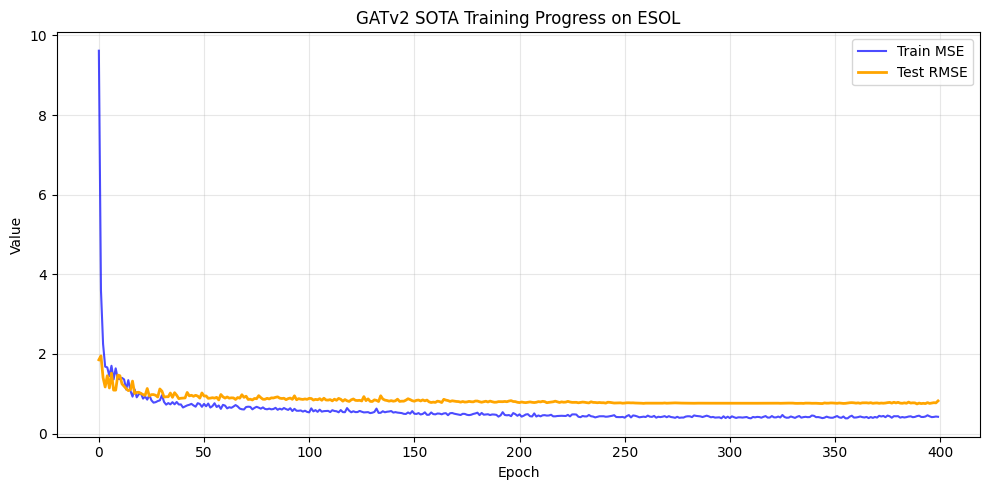

In [77]:
# =============================================================================
# SOTA GATv2 Training on ESOL – Fully Corrected & Clean Version
# =============================================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# Model instantiation
# ──────────────────────────────────────────────────────────────────────────────
gat_esol = GATv2ResSOTA(
    in_channels=esol.num_node_features,
    edge_dim=3,
    global_feat_dim=8,
    hidden_channels=128,
    heads=6,
    dropout=0.2
).to(device)

print(f"Starting SOTA GATv2 training on ESOL")
print(f"Final pooled dim: {gat_esol.pooled_dim}")
print(f"Model parameters: {sum(p.numel() for p in gat_esol.parameters()):,}")




# ──────────────────────────────────────────────────────────────────────────────
# Optimizer & Scheduler
# ──────────────────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    gat_esol.parameters(),
    lr=0.001,
    weight_decay=5e-5
)

from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-6)

# ──────────────────────────────────────────────────────────────────────────────
# Training hyperparameters
# ──────────────────────────────────────────────────────────────────────────────
max_epochs = 400
best_rmse = float('inf')
train_losses = []
test_rmses = []
test_maes = []

# ──────────────────────────────────────────────────────────────────────────────
# Training loop
# ──────────────────────────────────────────────────────────────────────────────
for epoch in range(1, max_epochs + 1):
    gat_esol.train()
    total_loss = 0.0
    n_graphs = 0

    for batch in esol_train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = gat_esol(batch)
        loss = F.mse_loss(out.squeeze(-1), batch.y.squeeze(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(gat_esol.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        n_graphs += batch.num_graphs

    avg_train_loss = total_loss / n_graphs if n_graphs > 0 else float('nan')
    train_losses.append(avg_train_loss)

    # ─── Evaluation ──────────────────────────────────────────────────────────
    gat_esol.eval()
    with torch.no_grad():
        rmse, mae, _, _ = eval_regression(esol_test_loader, gat_esol)

    test_rmses.append(rmse)
    test_maes.append(mae)

    scheduler.step()

    # Save best model
    if rmse < best_rmse:
        best_rmse = rmse
        torch.save(gat_esol.state_dict(), "best_esol_gatv2_sota.pt")
        print(f"→ New best RMSE: {rmse:.4f}   MAE: {mae:.4f}   (epoch {epoch})")

    # Progress printing
    if epoch <= 15 or epoch % 25 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:4d} | Train loss {avg_train_loss:.5f} | "
              f"Test RMSE {rmse:.4f} | MAE {mae:.4f} | LR {current_lr:.2e}")

    # Early stopping (loose)
    if epoch > 120 and rmse > best_rmse * 1.25:
        print(f"Early stopping triggered at epoch {epoch} "
              f"(RMSE {rmse:.4f} > 1.25× best {best_rmse:.4f})")
        break

# ──────────────────────────────────────────────────────────────────────────────
# Final summary + plot
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"Training finished after {epoch} epochs")
print(f"Best test RMSE : {best_rmse:.4f}")
print(f"Best MAE       : {min(test_maes):.4f}")
print(f"Best model saved: best_esol_gatv2_sota.pt")
print("="*70)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE', color='blue', alpha=0.7)
plt.plot(test_rmses, label='Test RMSE', color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('GATv2 SOTA Training Progress on ESOL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()